# EDA — Bilingual Sentiment Classification

Goals (each section answers one question):
1. Confirm the class distribution.
2. Verify the `title\n\nbody` structure and look at title vs body separately.
3. Review-length distribution → picks `max_length` for the transformer.
4. German vs English split (overall and per class).
5. Surface features (`!`, `*...*`, ALL-CAPS, repeated chars, emojis) — are any predictive?
6. Read sample reviews per class — sanity-check labels, spot sarcasm/ambiguity.

Findings go into the Methods and Data sections of the report.

## Setup

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 200)

train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print('train:', train.shape, '  test:', test.shape)
print('train ratio:', round(len(train) / (len(train) + len(test)), 3))
train.head(3)

train: (252000, 3)   test: (168000, 2)
train ratio: 0.6


,id,sentence,label
0,0,"Moderner Weihnachtsbaum in weiß\n\nDieses Jahr wollte ich keinen echten Baum und so hab ich mich für einen modernen kleinen in weiß entschieden. Als das Paket kam und ich den Baum ausgepackt hab, ...",4
1,1,"Passt wie angegossen\n\nTasche kam schnell und gut Verpackt an, die kleine DJI Ryze Tello passt perfekt rein sowie der Controller , zusätzlich sind noch 2 schlitze für Reserve Akkus und 3 Vertiefu...",4
2,2,Schlechte Qualität\n\nIch habe sehr lange auf diesen Käfig gespart. Leider muss ich mich den vorherigen Rezensionen anschließen. Die Qualität ist wirklich sehr schlecht. Überall ist das Holz gespl...,1


## 1. Class distribution

label
0    50400
1    50400
2    50400
3    50400
4    50400
Name: count, dtype: int64

percentages:
label
0    20.0
1    20.0
2    20.0
3    20.0
4    20.0
Name: count, dtype: float64


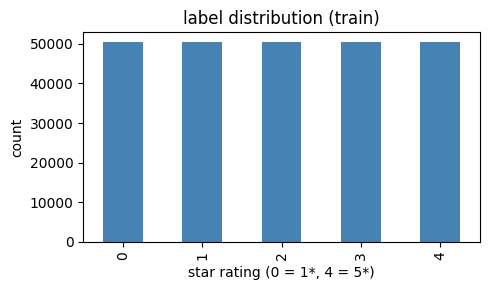

In [3]:
vc = train['label'].value_counts().sort_index()
print(vc)
print('\npercentages:')
print((vc / vc.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 3))
vc.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('label distribution (train)')
ax.set_xlabel('star rating (0 = 1*, 4 = 5*)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

**Expected:** ~50,400 per class. Perfectly balanced — no need for class weighting in the loss.

## 2. Title vs body structure

The slides say each review is a title sentence followed by a paragraph, separated by a blank line. If true, the title often carries the strongest sentiment signal and we may want to give it special treatment later.

In [4]:
def split_title_body(text: str):
    """Split on the first blank line. Falls back to (text, '')."""
    if not isinstance(text, str):
        return ('', '')
    parts = re.split(r'\n\s*\n', text, maxsplit=1)
    if len(parts) == 2:
        return parts[0].strip(), parts[1].strip()
    return parts[0].strip(), ''

tb = train['sentence'].apply(split_title_body)
train['title'] = tb.str[0]
train['body']  = tb.str[1]

has_body = (train['body'].str.len() > 0).mean()
print(f'reviews with a separate body: {has_body:.1%}')

print('\ntitle length (chars):')
print(train['title'].str.len().describe(percentiles=[.5, .9, .99]).round(1))

print('\nbody length (chars):')
print(train['body'].str.len().describe(percentiles=[.5, .9, .99]).round(1))

reviews with a separate body: 100.0%

title length (chars):
count    252000.0
mean         23.0
std          16.2
min           1.0
50%          19.0
90%          45.0
99%          79.0
max         128.0
Name: title, dtype: float64

body length (chars):
count    252000.0
mean        193.4
std         182.8
min          15.0
50%         143.0
90%         401.0
99%         891.0
max        3775.0
Name: body, dtype: float64


## 3. Review-length distribution

Picks the transformer's `max_length`. Too short → truncation loses signal; too long → wasted compute. Use ~99th percentile as a reasonable cap.

characters:
count    252000.0
mean        218.4
std         187.8
min          18.0
50%         168.0
90%         433.0
95%         564.0
99%         928.0
max        3845.0
Name: n_chars, dtype: float64

words:
count    252000.0
mean         37.5
std          32.7
min           2.0
50%          28.0
90%          75.0
95%          98.0
99%         161.0
max         737.0
Name: n_words, dtype: float64


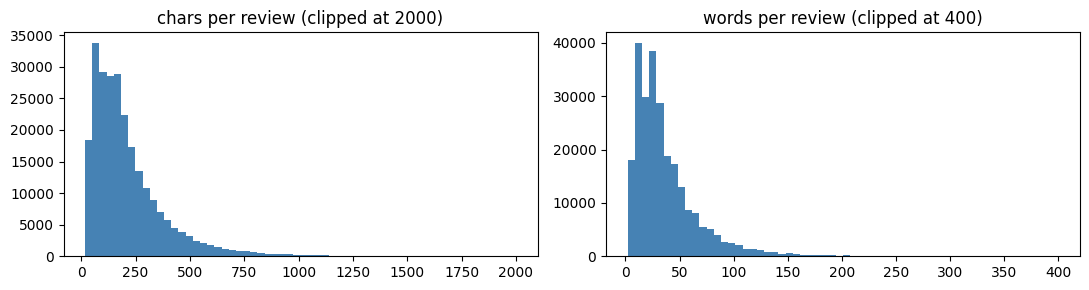

In [5]:
train['n_chars'] = train['sentence'].str.len()
train['n_words'] = train['sentence'].str.split().str.len()

print('characters:')
print(train['n_chars'].describe(percentiles=[.5, .9, .95, .99]).round(1))
print('\nwords:')
print(train['n_words'].describe(percentiles=[.5, .9, .95, .99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(train['n_chars'].clip(upper=2000), bins=60, color='steelblue')
axes[0].set_title('chars per review (clipped at 2000)')
axes[1].hist(train['n_words'].clip(upper=400), bins=60, color='steelblue')
axes[1].set_title('words per review (clipped at 400)')
plt.tight_layout()
plt.show()

In [6]:
# length vs label — do longer reviews skew positive or negative?
print(train.groupby('label')[['n_chars', 'n_words']].median().round(1))

       n_chars  n_words
label                  
0        166.0     28.0
1        190.0     33.0
2        178.0     31.0
3        167.0     28.0
4        144.0     24.0


## 4. Language: German vs English

Rough heuristic — checks for German-only characters (`ä ö ü ß`) and common German function words. Good enough for EDA; for the paper, swap in `fasttext-langdetect` or `langid`.

In [7]:
_DE_WORDS = (' der ', ' die ', ' das ', ' und ', ' ich ', ' nicht ', ' ist ', ' ein ', ' eine ', ' mit ', ' f\u00fcr ')
_DE_CHARS = ('\u00e4', '\u00f6', '\u00fc', '\u00df')  # ä ö ü ß

def guess_lang(text: str) -> str:
    t = (text or '').lower()
    if any(c in t for c in _DE_CHARS):
        return 'de'
    tp = f' {t} '
    if any(w in tp for w in _DE_WORDS):
        return 'de'
    return 'en'

train['lang'] = train['sentence'].apply(guess_lang)

print('overall:')
print(train['lang'].value_counts(normalize=True).round(3))

print('\nper class (rows sum to 1):')
print(pd.crosstab(train['label'], train['lang'], normalize='index').round(3))

overall:
lang
en    0.52
de    0.48
Name: proportion, dtype: float64

per class (rows sum to 1):
lang      de     en
label              
0      0.486  0.514
1      0.490  0.510
2      0.485  0.515
3      0.477  0.523
4      0.464  0.536


## 5. Surface features

The slides flag `!`, `*...*`, repeated characters, and emojis as informative. Let's check whether their frequency correlates with the label.

In [8]:
_REPEAT_RE = re.compile(r'(.)\1{2,}')                          # 3+ of the same char
_EMOJI_RE  = re.compile(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]')
_STAR_RE   = re.compile(r'\*[^*]+\*')                          # *bolded text*
_CAPS_RE   = re.compile(r'\b[A-Z\u00c4\u00d6\u00dc]{3,}\b')    # ALL-CAPS words len >= 3

feat = pd.DataFrame({
    'n_excl':     train['sentence'].str.count('!'),
    'n_question': train['sentence'].str.count(r'\?'),
    'has_star':   train['sentence'].str.contains(_STAR_RE).astype(int),
    'has_emoji':  train['sentence'].str.contains(_EMOJI_RE).astype(int),
    'has_repeat': train['sentence'].str.contains(_REPEAT_RE).astype(int),
    'n_caps':     train['sentence'].str.count(_CAPS_RE),
    'label':      train['label'],
})

print('mean per class:')
print(feat.groupby('label').mean().round(3))

/var/folders/m4/1h47g23d7pddfv7ny6dxhs9h0000gn/T/ipykernel_48008/2762235490.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_repeat': train['sentence'].str.contains(_REPEAT_RE).astype(int),


mean per class:
       n_excl  n_question  has_star  has_emoji  has_repeat  n_caps
label                                                             
0       0.737       0.084     0.001      0.012       0.194   0.328
1       0.303       0.057     0.001      0.010       0.174   0.175
2       0.229       0.048     0.001      0.010       0.156   0.144
3       0.334       0.024     0.001      0.014       0.109   0.124
4       0.699       0.013     0.001      0.020       0.099   0.138


## 6. Sample reviews per class

Read a few real reviews from each rating — confirms labels make sense and surfaces sarcasm / ambiguity to discuss in the report.

In [ ]:
for lbl in [0, 1, 2, 3, 4]:
    print('=' * 8, f'label = {lbl}', '=' * 8)
    sample = train[train['label'] == lbl].sample(3, random_state=lbl)
    for s in sample['sentence']:
        snippet = (s[:300] + '...') if len(s) > 300 else s
        print(snippet)
        print('-' * 40)
    print()

## Findings summary

- **Classes**: perfectly balanced (50,400 each = 20%). Standard cross-entropy is fine; no class weighting needed.
- **Title / body**: 100% of reviews have both a title and a body. Title is short (median 19 chars, 99% ≤ 79); body is longer (median 143 chars, 99% ≤ 891). Worth trying a title-aware model variant later.
- **Length**: review word count — median 28, 95th pct 98, 99th pct 161. `max_length = 256` tokens covers 99% comfortably with room for subword expansion.
- **Length × label**: slight U-shape — middle classes (label = 1, 2) are longest; 5-star reviews are shortest (median 24 words). 5-star reviewers say less.
- **Language**: ≈ 52% EN / 48% DE (heuristic — likely undercounts DE slightly). Distribution is uniform across classes (within ~1–2%). Multilingual encoder is the right tool.
- **Surface features**:
  - `!` is **U-shaped** (0.74 → 0.23 → 0.70 from label 0 to 4): signals *strength of emotion*, not direction. A model relying only on `!` will confuse 0★ with 5★.
  - `?` decreases monotonically (0.084 → 0.013): negative reviewers ask more rhetorical questions.
  - `*…*` bolding: essentially absent (0.001 everywhere). Drop as a feature.
  - Repeated chars (`sooooo`): decrease with rating (0.19 → 0.10). More common when negative.
  - ALL-CAPS words: peak at label 0 (0.33) and decline.
  - Emojis: mildly skew positive (1.0% → 2.0%).
- **Label quality**: random samples per class look honest. No obvious systematic mislabeling.

### Implications for the model
1. Use a **multilingual** pre-trained encoder (XLM-R, mDeBERTa-v3).
2. `max_length = 256` is enough — saves compute over 512.
3. The metric is MAE-based and `!` is U-shaped → train with an **ordinal-aware loss** (soft-label CE or CORN), not plain cross-entropy.
4. Worth ablating: include surface features as extra inputs vs. let the encoder learn them.